In [1]:
import numpy as np
from scipy import integrate

import sys
sys.path.append("../helpers")
from initial_dists import IMF, offner_multiplicity, p_q, p_log_porb

import matplotlib.pyplot as plt
import matplotlib as mpl

fs = 24
style_params = {
    'font.family': 'serif',
    'text.usetex': False,
    'figure.figsize': (12, 8),
    'axes.titlesize': 24,
    'legend.title_fontsize': 18,
    'legend.fontsize': 16,
    'axes.labelsize': 24,
    'xtick.labelsize': 21,
    'ytick.labelsize': 21,
    'axes.linewidth': 1.1,
    'xtick.major.size': 7,
    'xtick.minor.size': 4,
    'ytick.major.size': 7,
    'ytick.minor.size': 4,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
}
plt.rcParams.update(style_params)

%config InlineBackend.figure_format = 'retina'

In [2]:
def star_formation_mass_for_target(
        imf, f_bin, p_q, p_log_porb,
        m1_full_range, q_full_range, log_porb_full_range,
        m1_target_range, q_target_range, log_porb_target_range,
    ):
    """
    calculate the star formation mass needed to produce an expected number of
    target binaries, given a mass-dependent binary fraction and independent
    distributions for mass ratio and orbital period

    Parameters
    ----------
    imf : `callable`
        initial mass function for the primary mass, normalised over ``m1_full_range``
    f_bin : `callable`
        binary fraction as a function of primary mass, ``f_bin(m1)``
    p_q : `callable`
        mass ratio distribution, normalised over ``q_full_range``
    p_log_porb : `callable`
        logarithmic orbital period distribution, normalised over ``log_porb_full_range``
    m1_full_range : `tuple`
        (min, max) of the full primary mass support
    q_full_range : `tuple`
        (min, max) of the full mass ratio support
    log_porb_full_range : `tuple`
        (min, max) of the full logarithmic orbital period support
    m1_target_range : `tuple`
        (min, max) primary mass range of interest
    q_target_range : `tuple`
        (min, max) mass ratio range of interest
    log_porb_target_range : `tuple`
        (min, max) logarithmic orbital period range of interest

    Returns
    -------
    mean_system_mass : `float`
        mean total mass formed per system (single or binary)
    f_all : `float`
        fraction of all systems formed that are binaries in the target ranges
    """
    # mean primary mass and mass ratio over their full supports
    m1_mean = integrate.quad(lambda m1: imf(m1) * m1, *m1_full_range)[0]
    q_mean = integrate.quad(lambda q: p_q(q) * q, *q_full_range)[0]

    # mean total mass formed per system (single or binary)
    mean_system_mass = m1_mean + q_mean * integrate.quad(lambda m1: f_bin(m1) * imf(m1) * m1, *m1_full_range)[0]

    # fraction of all systems with primary mass in the target range that are binaries
    f_m = integrate.quad(lambda m1: imf(m1) * f_bin(m1), *m1_target_range)[0]

    # fraction of binaries in the target q and log_porb ranges
    f_q = integrate.quad(p_q, *q_target_range)[0]

    f_porb = integrate.quad(p_log_porb, *log_porb_target_range)[0]

    # fraction of all systems formed that are target binaries
    f_all = f_m * f_q * f_porb

    return mean_system_mass, f_all

In [4]:
mean_system_mass, f_all = star_formation_mass_for_target(
    imf=IMF, f_bin=offner_multiplicity,
    p_q=p_q, p_log_porb=p_log_porb,
    m1_full_range=(0.08, 150.0),
    q_full_range=(0.0, 1.0),
    log_porb_full_range=(0.15, 5.5),
    m1_target_range=(38.8, 47.8),
    q_target_range=(0.63, 0.88),
    log_porb_target_range=(1.71, 2.72),
)

print(f"mean system mass: {mean_system_mass:.2f} solar masses")
print(f"fraction of all systems in target range: {f_all:.1e}")

mean system mass: 0.76 solar masses
fraction of all systems in target range: 8.2e-06


In [5]:
f"{f_all / mean_system_mass * 0.46 * 1e6:.2e}"

'5.01e+00'

In [6]:
@np.vectorize
def p_at_least_one(sfr, delta_t):
    RATE = sfr * delta_t * f_all / mean_system_mass
    return 1 - np.exp(-RATE)

5.534856610775207
4197.591518426746


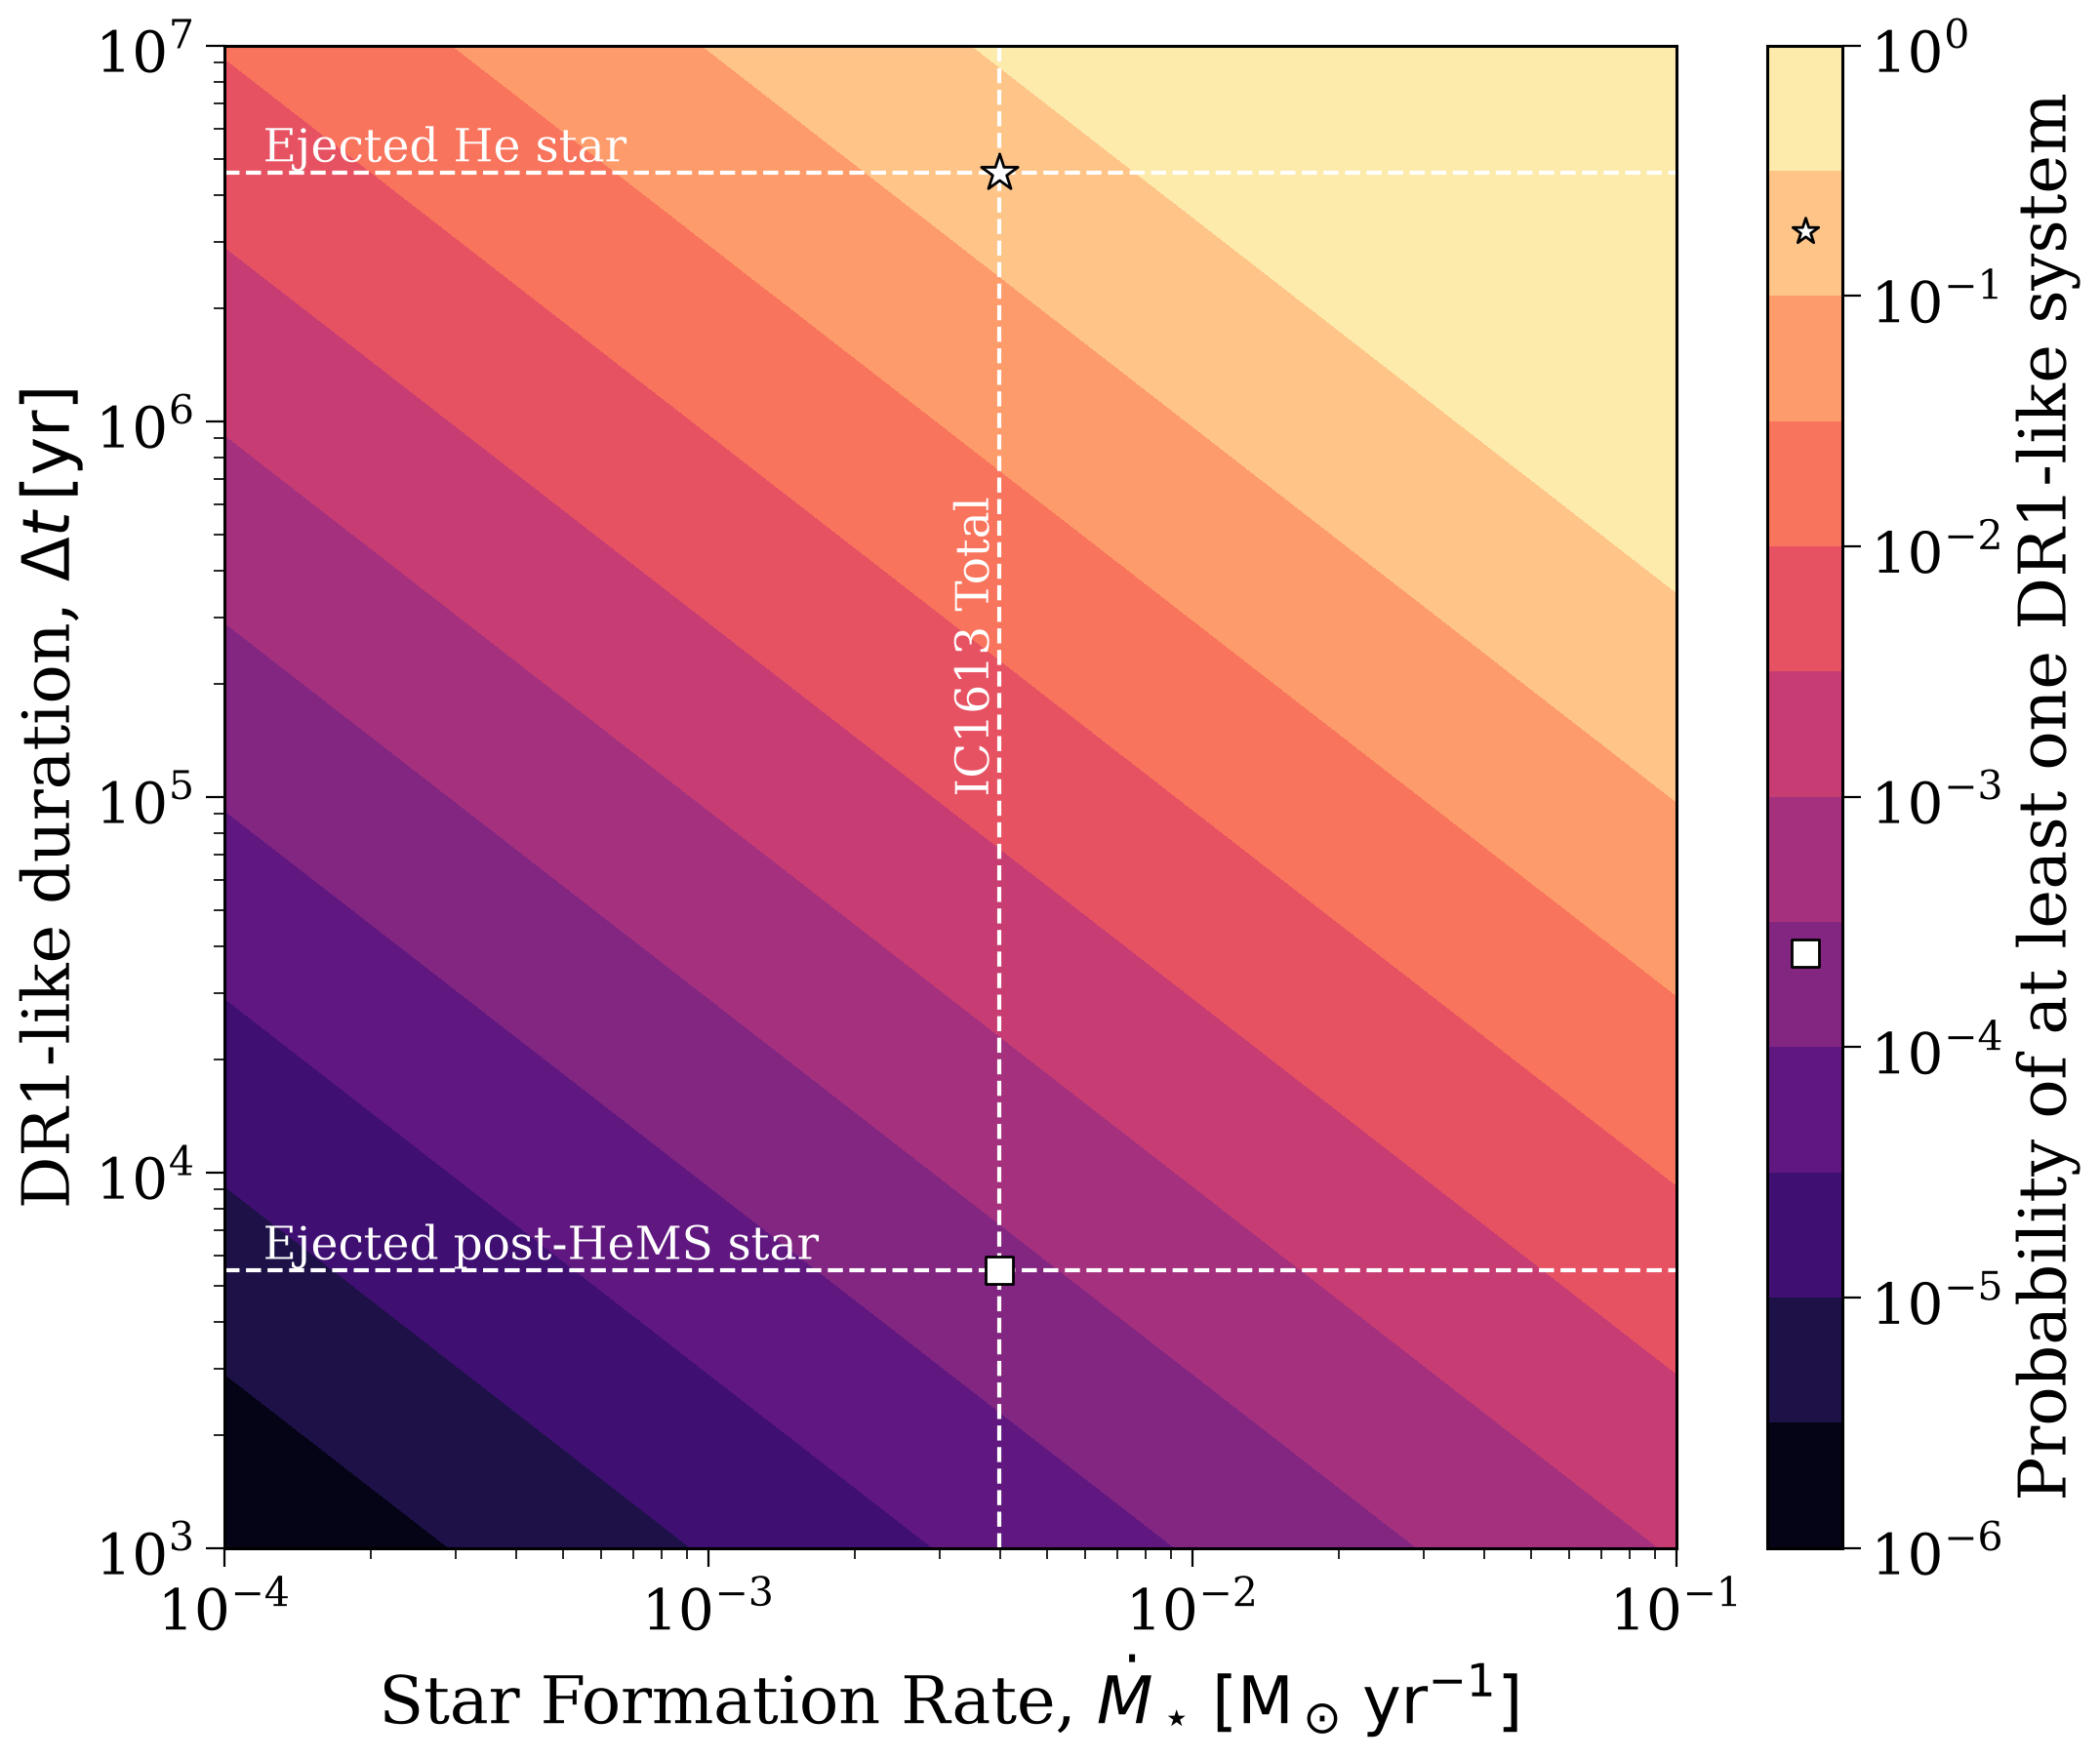

In [7]:
sfr_range = np.logspace(-4, -1, 100)
delta_t = np.logspace(3, 7, 101)

S, DT = np.meshgrid(sfr_range, delta_t)
P = p_at_least_one(S, DT)

fig, ax = plt.subplots(figsize=(12, 10))
cs = ax.contourf(S, DT, P, locator=mpl.ticker.LogLocator(), levels=np.logspace(-6, 0, 13), cmap='magma')
cbar = fig.colorbar(cs)
cbar.set_label('Probability of at least one DR1-like system')

SFR_LINES = [(10**(-2.4), "IC1613 Total")]
DELTA_T_LINES = [(4.6e6, "Ejected He star", "*"), (5.5e3, "Ejected post-HeMS star", "s")]

for sfr_line, sfr_label in SFR_LINES:
    ax.axvline(sfr_line, color="white", linestyle="--")
    ax.annotate(sfr_label, xy=(sfr_line, 1e5), color="white", fontsize=0.7*fs, rotation=90, va='bottom', ha='right')
    for delta_t_line, delta_t_label, marker in DELTA_T_LINES:
        ax.annotate(delta_t_label, xy=(1.2e-4, delta_t_line), color="white", fontsize=0.7*fs, va='bottom', ha='left')
        ax.axhline(delta_t_line, color="white", linestyle="--")
        ax.scatter(sfr_line, delta_t_line, color="white", s=200 if marker == "*" else 100, marker=marker, edgecolor='black', zorder=10)
        cbar.ax.scatter(0.5, p_at_least_one(sfr_line, delta_t_line), color="white", s=100, marker=marker, edgecolor='black', zorder=10)
        print(1 / p_at_least_one(sfr_line, delta_t_line))

ax.set(
    xscale='log',
    yscale='log',
    xlabel=r'Star Formation Rate, $\dot{M}_\star \, [{\rm M_\odot \, yr^{-1}}]$',
    ylabel=r'DR1-like duration, $\Delta t \, [{\rm yr}]$'
)

plt.savefig("../figures/dr1_formation_probability.pdf", format='pdf', bbox_inches='tight', dpi=300)

plt.show()